# MARL-mixed — multi-agent learning dynamics

This notebook summarizes the experiments added to **MARL-mixed**:

1. **JaxMARL sweep** — IPPO trained on *every registered JaxMARL environment*
   (one SLURM array task per game, GPU each), logging the learning dynamics.
2. **CRLD observability study** — the 2-agent / N-agent Iterated Prisoner's
   Dilemma with heterogeneous observability (deterministic learning dynamics).

Everything below is generated from saved artifacts in `results/` — no training
or GPU needed to re-run the notebook.

In [1]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 140, "savefig.dpi": 140})   # higher-res inline figures

HERE = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
RESULTS = os.path.join(HERE, "results")
REPO = os.path.dirname(HERE)
pd.set_option("display.max_rows", 100)
print("results dir:", RESULTS)

results dir: /nas/ucb/marimeireles/MARL-mixed/jaxmarl_env/results


## 1. Coverage across all JaxMARL environments

Each environment produced a `.status` file (`ok` / `skipped:<reason>` /
`failed:<reason>`). A single feed-forward, **discrete-action** IPPO trains the
discrete games directly; continuous-action games need a Gaussian policy head
(added separately) and a few image/dict-observation games need a CNN encoder.

In [2]:
rows = []
for s in sorted(glob.glob(os.path.join(RESULTS, "*.status"))):
    env = os.path.basename(s)[:-7]
    st = open(s).read().strip()
    kind = st.split(":", 1)[0]
    reason = st.split(":", 1)[1] if ":" in st else ""
    rows.append(dict(environment=env, status=kind, reason=reason))
cov = pd.DataFrame(rows)
summary = cov["status"].value_counts().rename("count").to_frame()
print(summary)
cov

        count
status       
ok         25
failed      5


,environment,status,reason
0,HeuristicEnemySMAX,ok,
1,LearnedPolicyEnemySMAX,failed,"TypeError(""LearnedPolicyEnemySMAX.__init__() m..."
2,MPE_simple_adversary_v3,ok,
3,MPE_simple_crypto_v3,ok,
4,MPE_simple_facmac_3a_v1,ok,
5,MPE_simple_facmac_6a_v1,ok,
6,MPE_simple_facmac_9a_v1,ok,
7,MPE_simple_facmac_v1,ok,
8,MPE_simple_push_v3,ok,
9,MPE_simple_reference_v3,ok,


## 2. Learning dynamics of the trained games

Reward per step vs. environment steps. Most games show clear improvement; hard exploration games (SMAX) stay near flat at this budget.

In [3]:
trained = []
for f in sorted(glob.glob(os.path.join(RESULTS, "*.npz"))):
    d = np.load(f)
    env = os.path.basename(f)[:-4]
    y = d["dynamics"]
    trained.append(dict(environment=env,
                        n_agents=int(d["num_agents"]),
                        reward_start=round(float(y[0]), 3),
                        reward_end=round(float(y[-1]), 3),
                        delta=round(float(y[-1] - y[0]), 3),
                        updates=len(y)))
perf = pd.DataFrame(trained).sort_values("delta", ascending=False).reset_index(drop=True)
perf

,environment,n_agents,reward_start,reward_end,delta,updates
0,MPE_simple_v3,1,-1.561,-0.259,1.302,610
1,ant_4x2,4,-0.210,0.793,1.004,610
2,MPE_simple_speaker_listener_v4,2,-1.467,-0.592,0.875,610
3,overcooked,2,0.000,0.623,0.623,610
4,MPE_simple_facmac_9a_v1,12,1.035,1.566,0.531,610
5,MPE_simple_reference_v3,2,-1.109,-0.685,0.424,610
6,MPE_simple_facmac_v1,4,0.027,0.371,0.343,610
7,MPE_simple_facmac_3a_v1,4,0.032,0.370,0.338,610
8,MPE_simple_push_v3,2,-0.576,-0.289,0.288,610
9,MPE_simple_spread_v3,3,-1.071,-0.786,0.285,610


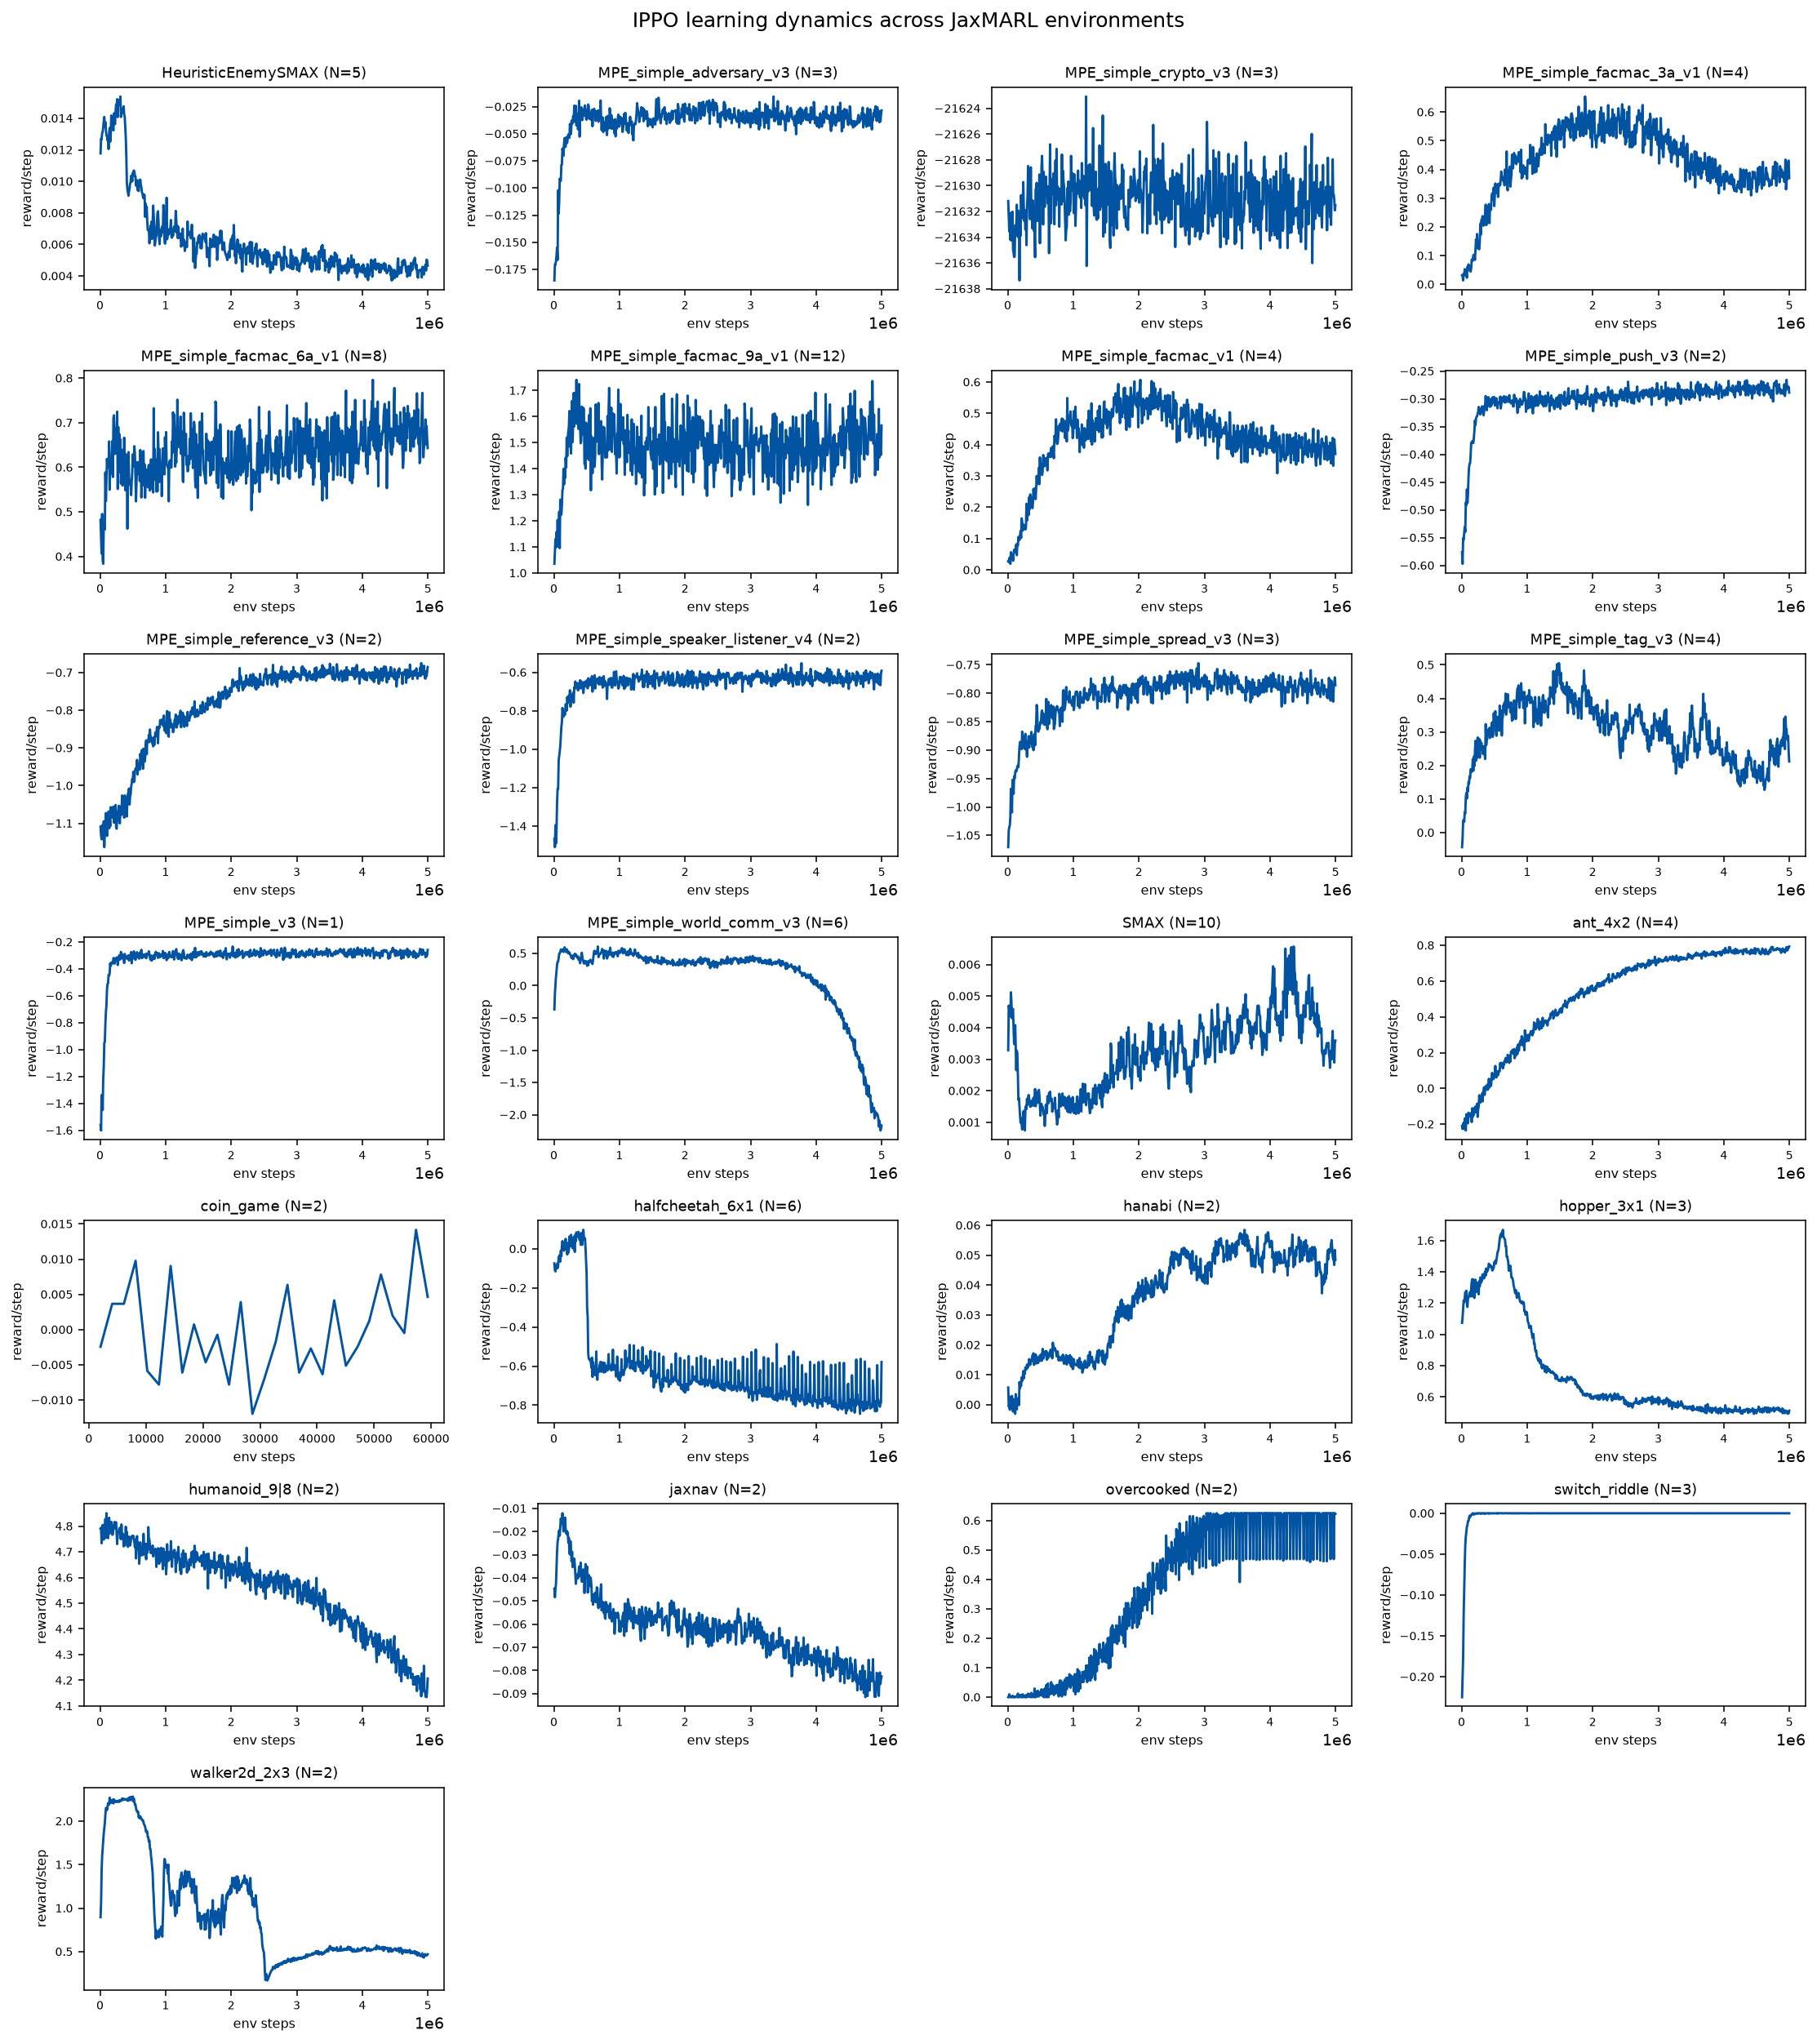

In [4]:
files = sorted(glob.glob(os.path.join(RESULTS, "*.npz")))
ncol = 4; nrow = (len(files) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol, 2.6*nrow), squeeze=False)
for ax in axes.flat: ax.axis("off")
for k, f in enumerate(files):
    d = np.load(f); ax = axes[k//ncol][k%ncol]; ax.axis("on")
    ax.plot(d["timesteps"], d["dynamics"], color="#0254a3")
    ax.set_title(f"{os.path.basename(f)[:-4]} (N={int(d['num_agents'])})", fontsize=9)
    ax.set_xlabel("env steps", fontsize=8); ax.set_ylabel("reward/step", fontsize=8)
    ax.tick_params(labelsize=7)
fig.suptitle("IPPO learning dynamics across JaxMARL environments", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()

### Skipped & failed — and why

- **skipped: continuous action space** — MaBrax robotic-control envs and the
  FACMAC MPE variants use `Box` actions; handled by the Gaussian-policy run
  (Section 4).
- **failed** — environment-specific API quirks (dict/image observations, a
  `make()` that needs extra args). Each is a localized follow-up.

In [5]:
notok = cov[cov.status != "ok"][["environment", "status", "reason"]]
notok.reset_index(drop=True)

,environment,status,reason
0,LearnedPolicyEnemySMAX,failed,"TypeError(""LearnedPolicyEnemySMAX.__init__() m..."
1,overcooked_v2,failed,TypeError('OvercookedV2.observation_space() ta...
2,storm,failed,"AttributeError(""'dict' object has no attribute..."
3,storm_2p,failed,"AttributeError(""'dict' object has no attribute..."
4,storm_np,failed,ValueError('Incompatible shapes for broadcasti...


## 3. Continuous control (MaBrax) — Gaussian policy

The discrete sweep above skips `Box`-action games. A Gaussian policy head lets
IPPO train the MaBrax robotic-control suite (`ant_4x2`, `halfcheetah_6x1`,
`hopper_3x1`, `humanoid_9|8`, `walker2d_2x3`). Their curves are loaded below once
that run has completed (look for `*_mabrax` / continuous entries in the table
above).

*This section auto-populates from the same `results/` directory, so re-running
the notebook after the MaBrax sweep finishes will show the new curves with no
code changes.*

In [6]:
mabrax = [r for r in trained if r["environment"] in
          {"ant_4x2","halfcheetah_6x1","hopper_3x1","humanoid_9|8","walker2d_2x3"}]
if mabrax:
    display(pd.DataFrame(mabrax))
else:
    print("MaBrax continuous results not present yet — run the Gaussian sweep, "
          "then re-execute this notebook.")

,environment,n_agents,reward_start,reward_end,delta,updates
0,ant_4x2,4,-0.210,0.793,1.004,610
1,halfcheetah_6x1,6,-0.075,-0.579,-0.504,610
2,hopper_3x1,3,1.073,0.511,-0.562,610
3,humanoid_9|8,2,4.791,4.207,-0.584,610
4,walker2d_2x3,2,0.895,0.470,-0.426,610


## 4. CRLD observability study (the original research question)

Before the deep-RL sweep, the core study uses **collective reinforcement
learning dynamics** (CRLD, the deterministic learning-dynamics limit) on the
Iterated Prisoner's Dilemma with *heterogeneous observability*: one agent sees
the full interaction, the other is selectively blind.

Key reproduced finding: **cooperation is fragile** — defection is the modal
attractor, and impairing observability suppresses cooperation monotonically;
losing the ability to observe one's *own* last action is uniquely catastrophic.

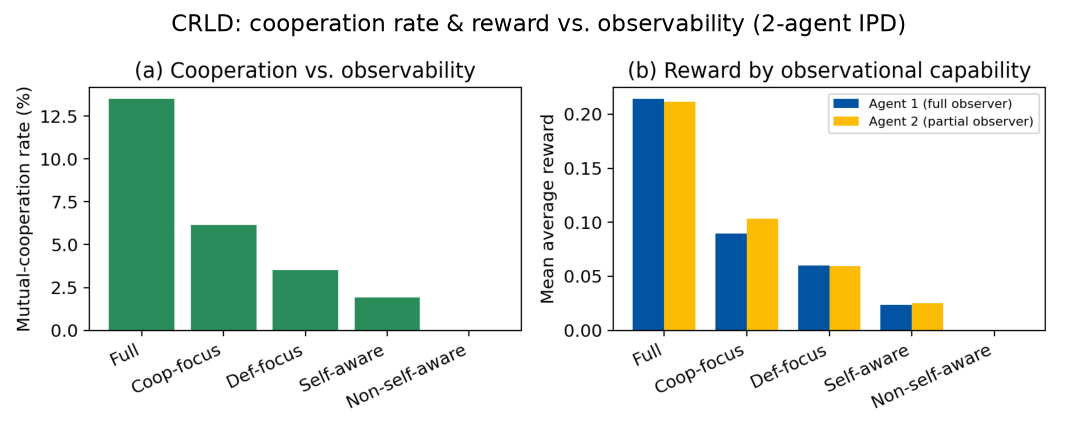

In [7]:
summ = os.path.join(REPO, "paper", "figures", "summary.png")
if os.path.exists(summ):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(11, 3.6)); ax.imshow(mpimg.imread(summ)); ax.axis("off")
    ax.set_title("CRLD: cooperation rate & reward vs. observability (2-agent IPD)")
    plt.show()
else:
    print("summary figure not found:", summ)

In [8]:
# N-agent extension: cooperation rate as a function of #agents x regime
csv = os.path.join(HERE, "coop_table.csv")
if os.path.exists(csv):
    display(pd.read_csv(csv))
else:
    print("coop_table.csv not found")

,regime,N=2,N=3,N=4
0,full,0.0,0.0,0.0
1,blind,0.0,0.0,0.0
2,self,0.0,0.0,0.0
3,others,0.0,0.0,0.0


## 5. CRLD flow plots — the dynamics of cooperation, done properly

**How to read these plots — there are TWO different things on them:**

1. **The little coloured arrows = the *flow field*.** At *every* point in strategy
   space (every combination of the two agents' cooperation probabilities), the
   arrow shows the direction the learning rule pushes the joint policy *next*.
   Think of it as wind, or the slope of a hill: it covers the whole square and
   tells you which way things move from anywhere. Colour = arrow strength.
2. **The single purple line = ONE actual learning *trajectory*.** Pick a random
   starting policy (the purple **×**), let the agents learn, and the policy drifts
   — always following the arrows — until it lands at a fixed point (the purple
   **dot**). It is one path *through* the flow field, like one leaf carried by the
   wind. (We draw two, from two random starts.)

So: **arrows = the rule everywhere; purple = one run obeying that rule.** The
flow field needs the analytic dynamics object (`mae`), which is why it only
exists for the CRLD social-dilemma games, not the sampled deep-RL runs.

The cell below runs the canonical example *live* (pyCRLD now runs in the same
Python 3.11 environment as JaxMARL — forced onto CPU for the small CRLD compute).

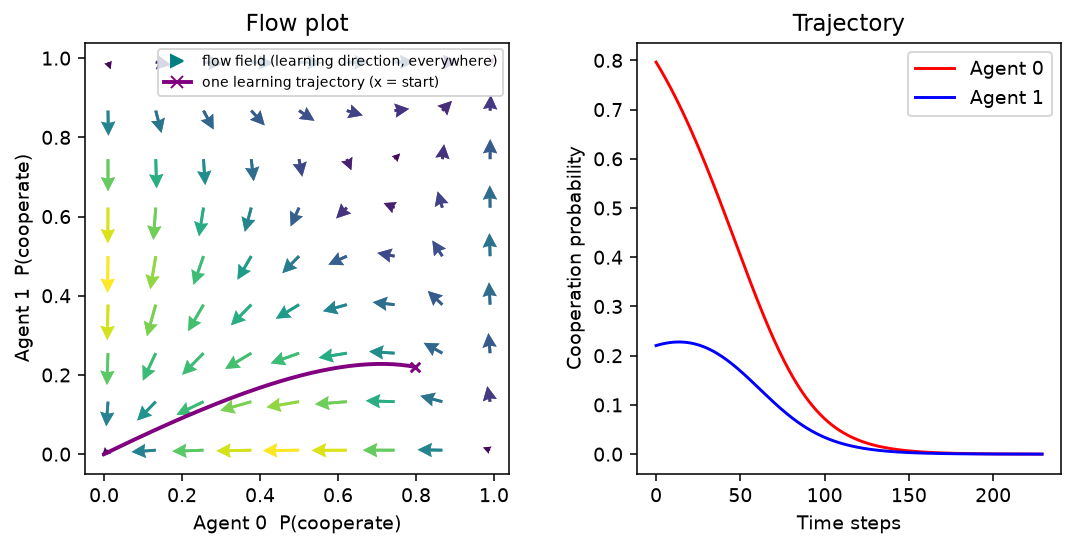

In [9]:
import os as _os
_os.environ.setdefault("JAX_PLATFORMS", "cpu")   # CRLD compute is tiny; CPU avoids GPU setup
import sys as _sys
_sys.path.insert(0, REPO)
import numpy as _np
from pyCRLD.Agents.StrategyActorCritic import stratAC
from pyCRLD.Environments.SocialDilemma import SocialDilemma
from pyCRLD.Utils import FlowPlot as fp

env = SocialDilemma(R=1.0, T=0.8, S=-0.5, P=0.0)
mae = stratAC(env=env, learning_rates=0.1, discount_factors=0.9)
_np.random.seed(0)
xtraj, reached = mae.trajectory(mae.random_softmax_strategy(), Tmax=10000, tolerance=1e-5)

fig, axs = plt.subplots(1, 2, figsize=(9, 4)); plt.subplots_adjust(wspace=0.3)
xs = ([0], [0], [0]); ys = ([1], [0], [0])
ax = fp.plot_strategy_flow(mae, xs, ys, use_RPEarrows=False,
                           flowarrow_points=_np.linspace(0.01, 0.99, 9), axes=[axs[0]])
fp.plot_trajectories([xtraj], xs, ys, cols=["purple"], axes=ax)
axs[0].set_xlabel("Agent 0  P(cooperate)"); axs[0].set_ylabel("Agent 1  P(cooperate)")
axs[0].set_title("Flow plot")
# explicit legend so the two elements are unmistakable
from matplotlib.lines import Line2D as _L
axs[0].legend(handles=[
    _L([0],[0], color="teal", marker=">", ls="none", label="flow field (learning direction, everywhere)"),
    _L([0],[0], color="purple", lw=2, marker="x", label="one learning trajectory (x = start)"),
], fontsize=7, loc="upper right")
axs[1].plot(xtraj[:, 0, 0, 0], label="Agent 0", c="red")
axs[1].plot(xtraj[:, 1, 0, 0], label="Agent 1", c="blue")
axs[1].set_xlabel("Time steps"); axs[1].set_ylabel("Cooperation probability")
axs[1].legend(); axs[1].set_title("Trajectory")
plt.show()

Sweeping the temptation `T` moves the game along the dilemma axis — and the
flow reorganizes from cooperation-attracting (Harmony) to defection-attracting
(Prisoner's Dilemma). Purple lines are trajectories from several random starts.

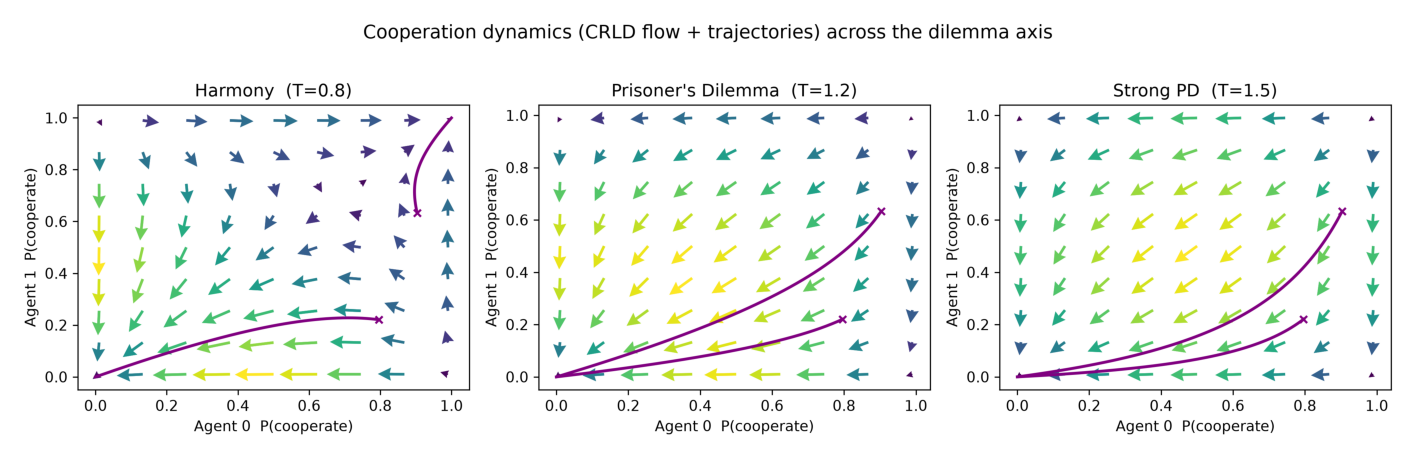

In [10]:
img = os.path.join(RESULTS, "payoff_sweep.png")
if os.path.exists(img):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(13, 4)); ax.imshow(mpimg.imread(img)); ax.axis("off")
    plt.show()
else:
    print("run scratch_repro/flowplots.py to generate payoff_sweep.png")

### Dynamics for *more games* — the four canonical 2x2 games

The same flow machinery applies to any 2x2 game, and each game has a
qualitatively different cooperation dynamic (R=1, P=0 fixed; T, S vary):
**Harmony** (cooperation dominant → flows to (1,1)), **Stag Hunt** (bistable: two
basins, cooperate or defect, split by a separatrix), **Snowdrift/Chicken**
(anti-coordination → an interior/off-diagonal attractor), and the **Prisoner's
Dilemma** (defection dominant → flows to (0,0)).

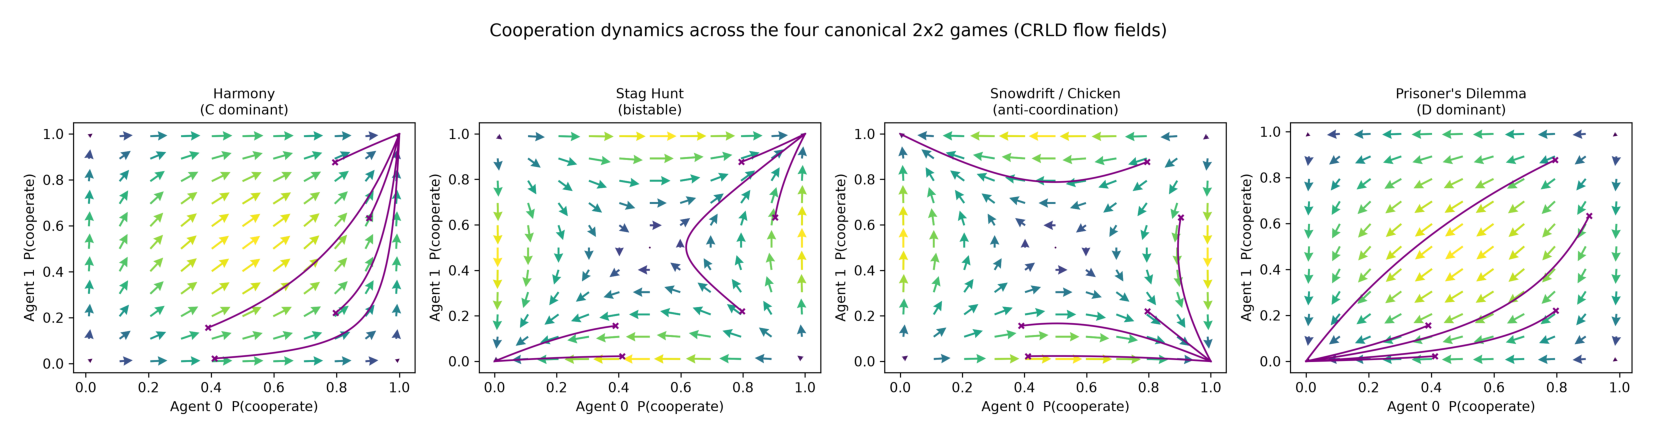

In [11]:
img = os.path.join(RESULTS, "game_menagerie.png")
if os.path.exists(img):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(15, 4)); ax.imshow(mpimg.imread(img)); ax.axis("off")
    plt.show()
else:
    print("run scratch_repro/flowplots.py to generate game_menagerie.png")

### Dynamics for *more algorithms* — paths over the flow field

Deep-RL algorithms have no analytic flow field, but their learning *paths* are
dynamics too. Below, the grey arrows are the CRLD memoryless-IPD prediction (which
points to defection); the coloured lines are the actual IPPO / A2C / IQL
trajectories on the memory-1 IPD. **IPPO and A2C ride the grey flow down to (0,0);
IQL climbs *against* it to (1,1)** — value-based learning plus memory escapes the
basin the memoryless dynamics predict. That deviation is the whole story.

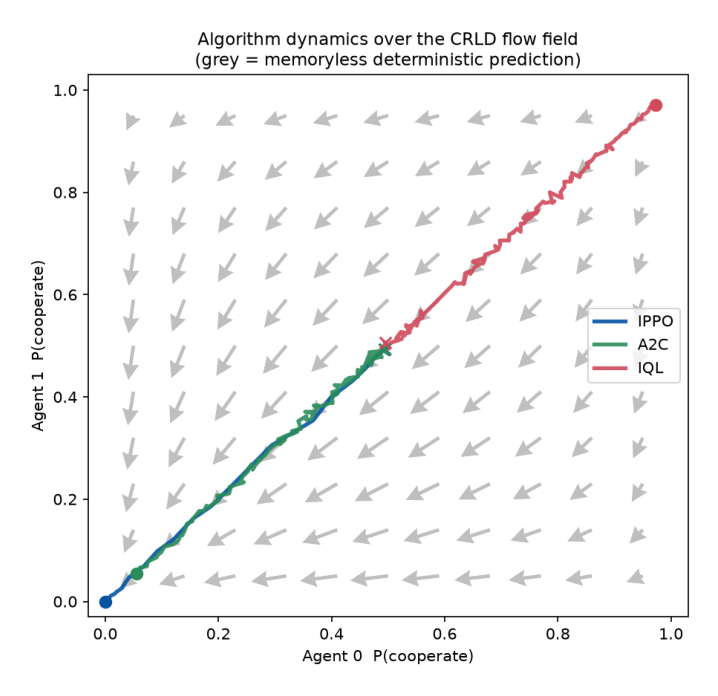

In [12]:
img = os.path.join(RESULTS, "algo_phase_full.png")
if os.path.exists(img):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(6.5, 6.2)); ax.imshow(mpimg.imread(img)); ax.axis("off")
    plt.show()
else:
    print("run algo_phase.py to generate algo_phase_full.png")

### Observation heterogeneity, with the flow field — all six regimes

Now the actual research question, *with arrows*, for **every** observability
regime: a **memory-1** IPD where Agent 1's observation is degraded in a different
way, shown in the state where both agents just cooperated (where reciprocity
lives). Coloured arrows = the learning-dynamics flow; the two purple lines =
trajectories from random starts. The six regimes are **full**, **self-aware**
(sees own action only), **non-self-aware** (sees the other's only),
**cooperation-tracking** (sees the other only when it cooperated),
**defection-tracking** (sees it only when it defected), and **blind**. Under full
observability the flow has structure that can sustain cooperation; as Agent 1's
view is masked the flow reorganises toward mutual defection — the **blind** field
points almost uniformly at (0, 0).

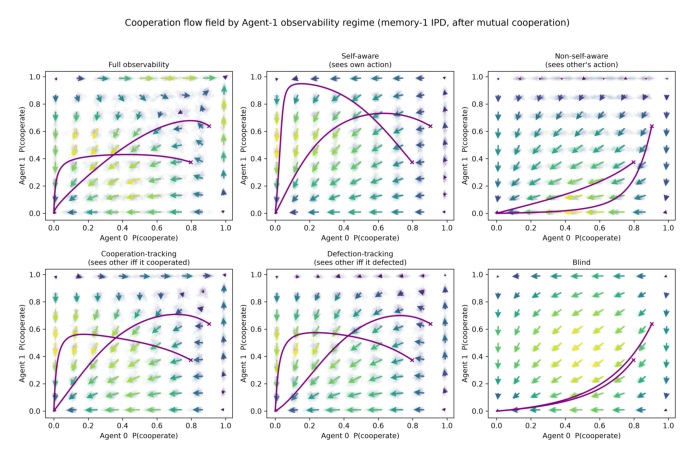

In [13]:
img = os.path.join(RESULTS, "memory_observability.png")
if os.path.exists(img):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(14, 4)); ax.imshow(mpimg.imread(img)); ax.axis("off")
    plt.show()
else:
    print("run scratch_repro/flowplots.py to generate memory_observability.png")

## 6. Cooperation phase portraits in deep RL — *why these have no arrows*

The plots below are the **sampled deep-RL** analogue: P(cooperate) trajectories
from IPPO on the same observability regimes. They have **no flow-field arrows on
purpose** — a flow field is the *analytic* learning-dynamics vector field, which
only exists for the CRLD model (Section 5). Neural-network policies trained by
sampling give you the realized *path*, but not a closed-form update direction at
every point in strategy space, so there is nothing to draw arrows from. (This is
the same reason the broader JaxMARL games in Section 2 get reward curves, not flow
plots.) Here every regime collapses to mutual defection — the deep-RL echo of the
CRLD result.

For the games where **cooperation** is genuinely defined (the mixed-motive
social dilemma), we can draw the *dynamics of cooperation* directly, in the
style of pyCRLD's `fp.plot_trajectories`: train IPPO while logging each agent's
cooperation frequency P(play C) per update, then trace the joint policy's path
through the **(agent-1 cooperation, agent-2 cooperation)** plane.

Below: the heterogeneous-observation memory-1 IPD (N=2) under each observability
regime. `x` marks the (random) start, `o` the converged policy. Under every
regime the trajectory collapses toward mutual defection (0, 0) — the deep-RL
echo of the CRLD result that defection is the dominant attractor; the regimes
differ in *how* they get there and how much residual cooperation survives.

*(Most JaxMARL games are forced-cooperative or non-dilemma, so a C/D cooperation
axis is not defined for them — for those, the reward curves in Section 2 are the
learning dynamics.)*

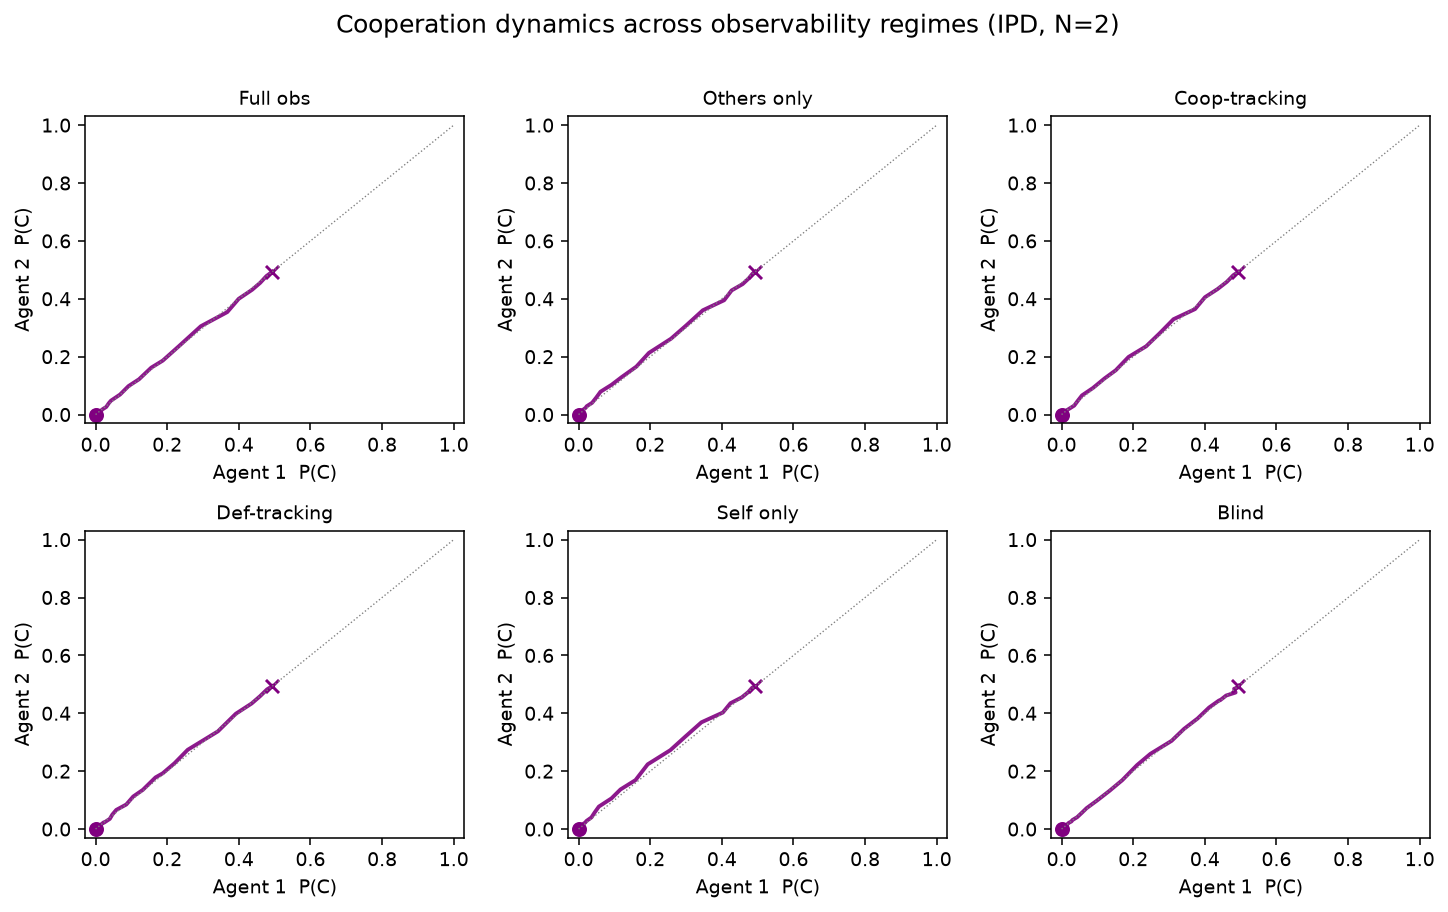

In [14]:
coop = sorted(f for f in glob.glob(os.path.join(RESULTS, "coop_*.npy"))
              if "vs_n" not in f)   # regime trajectories only
if coop:
    names = {"full":"Full obs","blind":"Blind","self":"Self only","others":"Others only",
             "coop":"Coop-tracking","def":"Def-tracking"}
    order = ["full","others","coop","def","self","blind"]
    have = {os.path.basename(f)[5:-4]: np.load(f) for f in coop}
    regs = [r for r in order if r in have] + [r for r in have if r not in order]
    ncol = 3; nrow = (len(regs)+ncol-1)//ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.5*ncol, 3.3*nrow), squeeze=False)
    for ax in axes.flat: ax.axis("off")
    for k, r in enumerate(regs):
        t = have[r]; ax = axes[k//ncol][k%ncol]; ax.axis("on")
        ax.plot(t[:,0], t[:,1], lw=2, color="purple", alpha=0.9)
        ax.scatter(t[0,0], t[0,1], color="purple", marker="x", s=45)
        ax.scatter(t[-1,0], t[-1,1], color="purple", marker="o", s=45)
        ax.plot([0,1],[0,1], ls=":", c="gray", lw=0.7)
        ax.set_xlim(-0.03,1.03); ax.set_ylim(-0.03,1.03)
        ax.set_title(names.get(r,r), fontsize=10)
        ax.set_xlabel("Agent 1  P(C)"); ax.set_ylabel("Agent 2  P(C)")
    fig.suptitle("Cooperation dynamics across observability regimes (IPD, N=2)", fontsize=13)
    fig.tight_layout(rect=[0,0,1,0.97]); plt.show()
    pd.DataFrame([{"regime":r,
                   "start": tuple(np.round(have[r][0],2)),
                   "end": tuple(np.round(have[r][-1],2))} for r in regs])
else:
    print("coop_*.npy not present yet — run coop_trajectories.py")

## 7. Algorithm comparison — IPPO vs A2C vs IQL

Does the *learning algorithm* change cooperation? We train three MARL families on
the same heterogeneous-observation IPD and log cooperation:

- **IPPO** — clipped policy-gradient actor-critic
- **A2C** — independent advantage actor-critic (on-policy, no clipping)
- **IQL** — independent Q-learning (value-based, epsilon-greedy)

They behave strikingly differently: the **policy-gradient** methods (IPPO, A2C)
drift to mutual defection, while **value-based IQL converges to cooperation
(~0.95)** — in every regime *except blind*, where it too collapses (~0.05).

**My read on why this happens:**
- **IPPO / A2C defect** because they are *on-policy policy gradient*. The gradient
  follows the immediate advantage, and in a Prisoner's Dilemma defection has
  positive advantage at every step (T>R, P>S — defection dominates the stage
  game). So the policy is pushed relentlessly to (0,0). This is exactly the CRLD
  flow field of Section 5 — the deterministic learning dynamics *are* the
  policy-gradient limit, and they point to defection.
- **IQL cooperates** because it is *value-based and bootstrapped*. Mutual
  cooperation is a self-reinforcing fixed point of the Q-values: once both agents
  mostly cooperate, the estimated value of cooperating (a stream of R=1) exceeds
  that of defecting (which provokes the partner's defection → P=0). The slow
  target network and greedy action selection let this high-value cooperative
  equilibrium lock in — the well-documented "Q-learning collusion" effect.
- **IQL needs observability to do it.** When *blind*, the agent has a single
  observation and cannot condition its action on history — and reciprocity
  ("cooperate if you cooperated") is exactly a conditional rule. With nothing to
  condition on, unconditional defection wins, so blind IQL collapses. Cooperation
  here requires *both* a value-based learner *and* the ability to observe — tying
  the algorithm axis back to the observation-heterogeneity theme.
- **A2C is intermediate and noisy** (e.g. its odd blind=0.43) because the
  un-clipped, single-update actor-critic is high-variance and under-converged; run
  longer it drifts toward IPPO's defection.

So "do agents cooperate?" depends as much on the algorithm as on the game.

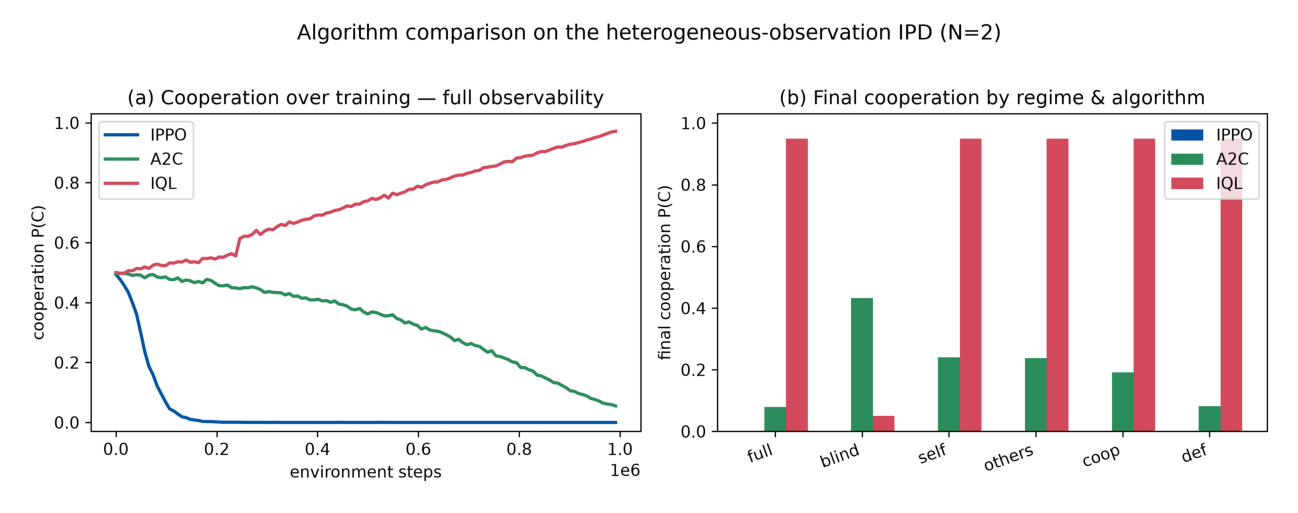

,full,blind,self,others,coop,def
IPPO,0.00,0.00,0.00,0.00,0.00,0.00
A2C,0.08,0.43,0.24,0.24,0.19,0.08
IQL,0.95,0.05,0.95,0.95,0.95,0.95


In [15]:
img = os.path.join(RESULTS, "algo_compare.png")
if os.path.exists(img):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(12.5, 4.5)); ax.imshow(mpimg.imread(img)); ax.axis("off")
    plt.show()
    af = os.path.join(RESULTS, "algo_final.npy")
    if os.path.exists(af):
        final = np.load(af)
        algos, regs = np.load(os.path.join(RESULTS, "algo_final_axes.npy"), allow_pickle=True)
        display(pd.DataFrame(np.round(final, 2), index=list(algos), columns=list(regs)))
else:
    print("run algo_compare.py to generate the comparison")

## 7b. Does the learning rate change cooperation?

On the CRLD side we found that a *smaller* learning rate enlarges the cooperative
basin (smaller, more careful steps settle into cooperative fixed points that
larger steps overshoot). Here we sweep the learning rate for each algorithm on
the full-observability IPD.

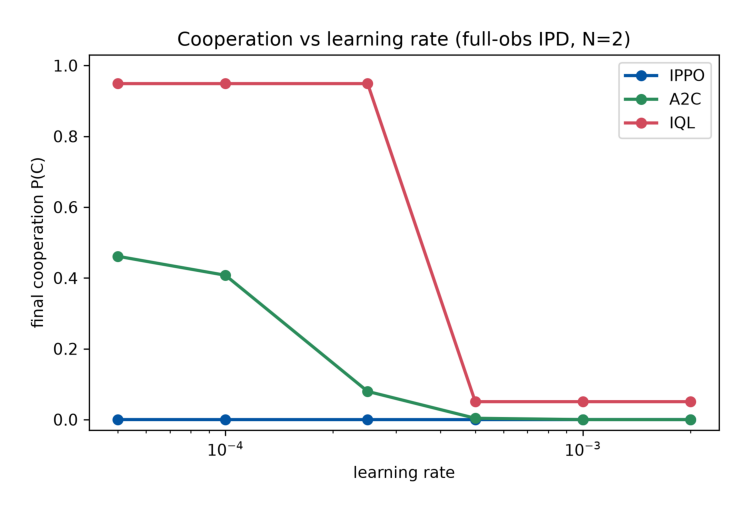

,5e-05,1e-04,3e-04,5e-04,1e-03,2e-03
IPPO,0.00,0.00,0.00,0.00,0.00,0.00
A2C,0.46,0.41,0.08,0.00,0.00,0.00
IQL,0.95,0.95,0.95,0.05,0.05,0.05


In [16]:
img = os.path.join(RESULTS, "lr_sweep.png")
if os.path.exists(img):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(7, 4.5)); ax.imshow(mpimg.imread(img)); ax.axis("off")
    plt.show()
    lf = os.path.join(RESULTS, "lr_sweep.npy")
    if os.path.exists(lf):
        M = np.load(lf)
        algos, lrs = np.load(os.path.join(RESULTS, "lr_sweep_axes.npy"), allow_pickle=True)
        display(pd.DataFrame(np.round(M, 2), index=list(algos),
                             columns=[f"{l:.0e}" for l in lrs]))
else:
    print("run lr_sweep.py to generate the learning-rate sweep")

**My read on the learning-rate result** (and it lines up nicely with the CRLD
α-finding that smaller learning rates enlarge the cooperative basin):

- **IPPO: pinned at defection for every rate.** Once the policy gradient commits
  to the dominant action, step size changes only *how fast* it reaches (0,0), not
  *where* it lands — no learning rate rescues it.
- **A2C: smooth, monotone — smaller rate → more cooperation** (0.46 at 5e-5, down
  to 0.0 by 1e-3). This is the direct deep-RL echo of the CRLD result: small,
  careful steps let the on-policy learner *linger in and settle toward* the
  cooperative region before the defection gradient drags it out, whereas large
  steps overshoot straight to defection.
- **IQL: a sharp threshold (~5e-4).** Below it, cooperation locks in at ~0.95;
  above it, it collapses to ~0.05. The cooperative equilibrium lives in the
  *bootstrapped* Q-values stabilised by the slow target network; once the step
  size is large enough to outrun the target updates, the bootstrap no longer
  converges to the cooperative fixed point and value-based collusion fails.

Net: step size sets *speed and stability*, and for the value-based and
unregularised actor-critic learners it also moves the **basin boundary** — small
rates are pro-cooperation — exactly the lever we identified on the CRLD side.

## 7c. More general-sum games, across algorithms

The IPD is one general-sum game; here are the same three algorithms on several
others available in JaxMARL — `coin_game` (the canonical deep-RL social dilemma),
and the general-sum MPE games (`simple_tag` predator-prey, `simple_adversary`,
`simple_push`). We plot the reward dynamics per algorithm.

On the **"arena" question:** the closest thing JaxMARL has to an arena is **STORM**
(the "in-the-matrix" gridworld games, e.g. `storm_2p`), which embeds general-sum
matrix games spatially. They are general-sum, but their observation is an
image/grid that collapses to nothing when flattened, so a feed-forward policy
can't use them — they need a CNN encoder (a clean next step, not done here).

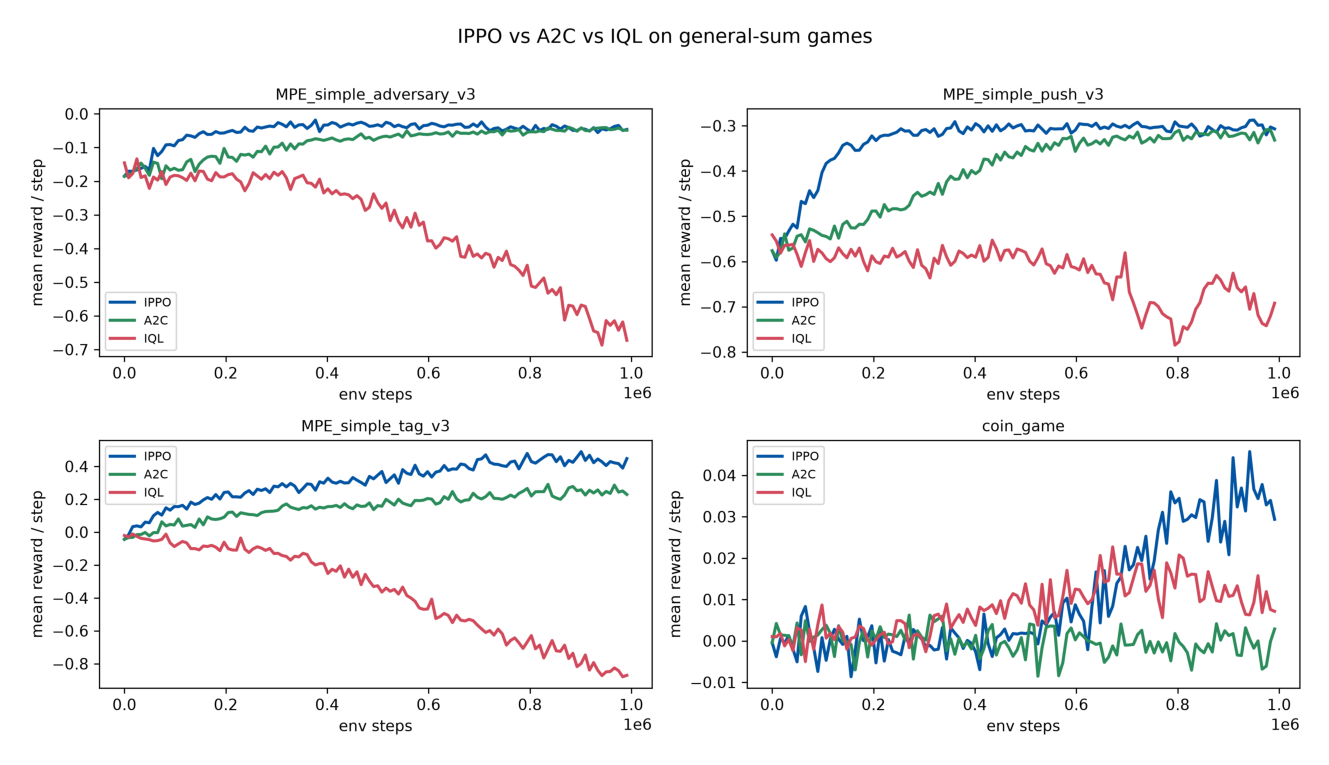

In [17]:
img = os.path.join(RESULTS, "gen_compare.png")
if os.path.exists(img):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(12, 7)); ax.imshow(mpimg.imread(img)); ax.axis("off")
    plt.show()
else:
    print("run gen_compare.py to generate the general-sum comparison")

**My read across games:** there is no universally-best algorithm — the ranking
*flips with the game*. On the IPD, **IQL** was the only one to cooperate; but on
the MPE games (`tag`, `adversary`, `push`) **IQL diverges** (reward falls), while
the policy-gradient methods **IPPO** (most robust) and **A2C** steadily improve.
Why: those MPE tasks are highly non-stationary multi-agent control problems
(pursuit, keep-away) with several simultaneously-adapting opponents. Independent
Q-learning bootstraps off a moving target whose drift it cannot model, so its
value estimates chase a target that keeps moving and destabilise — the same
bootstrapping that *helped* it lock into the IPD's cooperative fixed point *hurts*
it here. Policy-gradient methods optimise the current return directly and degrade
more gracefully. So "which algorithm cooperates / wins?" is not a property of the
algorithm alone — it is the algorithm × game × (as we saw) the observability and
learning rate, together.

## 7d. Does longer memory help cooperation?

Everything above used memory-1 (agents condition on the previous round). The IPD
env now supports memory-`m`; here we sweep it for each algorithm (full obs).

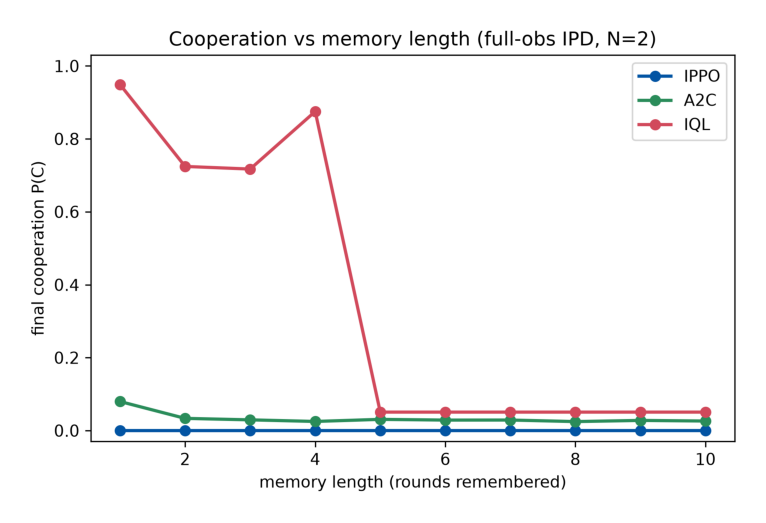

,mem=1,mem=2,mem=3,mem=4,mem=5,mem=6,mem=7,mem=8,mem=9,mem=10
IPPO,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
A2C,0.08,0.03,0.03,0.03,0.03,0.03,0.03,0.02,0.03,0.03
IQL,0.95,0.72,0.72,0.88,0.05,0.05,0.05,0.05,0.05,0.05


In [18]:
img = os.path.join(RESULTS, "memory_sweep.png")
if os.path.exists(img):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(7, 4.6)); ax.imshow(mpimg.imread(img)); ax.axis("off")
    plt.show()
    mf = os.path.join(RESULTS, "memory_sweep.npy")
    if os.path.exists(mf):
        M = np.load(mf)
        algos, mems = np.load(os.path.join(RESULTS, "memory_sweep_axes.npy"), allow_pickle=True)
        display(pd.DataFrame(np.round(M, 2), index=list(algos),
                             columns=[f"mem={m}" for m in mems]))
else:
    print("run memory_sweep.py to generate the memory sweep")

**My read on memory (now swept to 10):** more memory does **not** buy more
cooperation — and at enough depth it actively **destroys** it. IPPO/A2C are flat
(they defect at every memory length). IQL is the striking case: its cooperation
holds through memory~4 (0.72-0.95) and then **falls off a cliff to ~0.05 for
memory ≥ 5** and stays there. The reason: the cooperative strategies that matter
(tit-for-tat, win-stay-lose-shift) are already **memory-1** strategies, so extra
history adds no *needed* capability — it only multiplies the observation space
(it grows by 2N per round: memory-10 is a 41-dim observation). Past a threshold,
that blow-up is more than the fixed sample budget can fit, and the value-based
learner can no longer find the cooperative fixed point, so it defaults to
defection. So memory depth is not a cooperation lever — beyond what reciprocity
needs, it is a *liability*; observability and the algorithm family are what
matter.

## 7e. 🍲 Overcooked — image observations via a CNN

Overcooked is a *cooperative* game with a **spatial-grid observation** (4x5x26)
and a **sparse** reward (you only score when a dish is delivered). It needs (a) a
**CNN** encoder, and (b) **shaped-reward** training (the env exposes
`info["shaped_reward"]` for picking up onions, using the pot, etc.) to learn at
all. We train all three algorithms with the CNN and shaped rewards, and plot the
*sparse* task reward (real dishes).

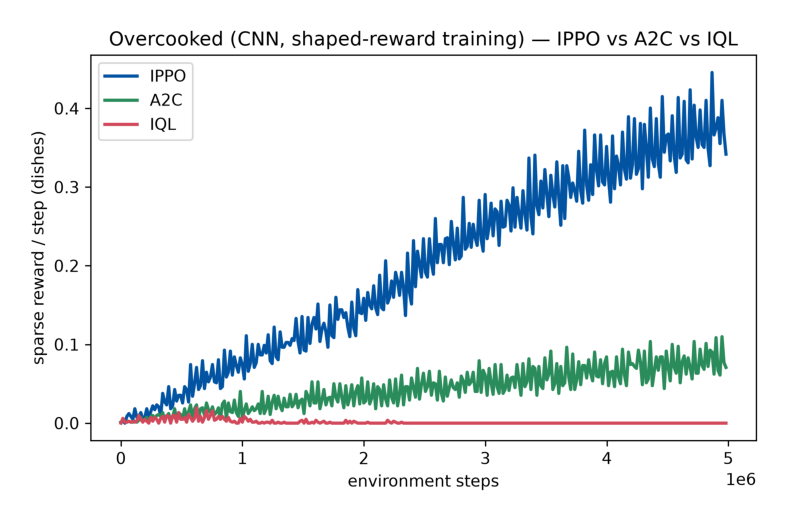

In [19]:
img = os.path.join(RESULTS, "overcooked_compare.png")
if os.path.exists(img):
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(7, 4.6)); ax.imshow(mpimg.imread(img)); ax.axis("off")
    plt.show()
else:
    print("run img_compare.py (CNN, shaped reward) to generate the Overcooked comparison")

**My read on Overcooked:** the CNN + shaped reward work — **IPPO learns to
deliver dishes** (sparse reward climbs to ~0.34), **A2C** learns slowly (~0.10),
and **IQL flat-lines (~0)**. Note this is the *opposite* ranking from the IPD,
where IQL was the cooperation champion. Overcooked is a sparse-reward,
long-horizon *spatial coordination* task; independent Q-learning has to propagate
a rare reward back through many steps while its partner is also changing, and its
bootstrapped value estimates never get traction. Policy-gradient methods optimise
the (shaped) return directly and make steady progress. Once again: **the best
algorithm is a property of the game, not the algorithm** — IQL wins the matrix
dilemma, IPPO wins the spatial cooperative task.

## 8. What was added to this repository

| path | what it is |
|---|---|
| `jaxmarl_env/heterogeneous_ipd.py` | N-player memory-1 IPD as a JaxMARL `MultiAgentEnv`, 6 observability regimes |
| `jaxmarl_env/train_ippo.py` | shared-policy feed-forward IPPO for the IPD (discrete) |
| `jaxmarl_env/run_all.py` | generic IPPO driver: trains one JaxMARL env, logs dynamics (discrete **and** Gaussian-continuous) |
| `jaxmarl_env/slurm_sweep.sh` | SLURM array job — one task per registered env |
| `jaxmarl_env/plot_all.py` | coverage report + combined dynamics grid |
| `jaxmarl_env/sweep_table.py` | regime x N cooperation table for the IPD |
| `jaxmarl_env/coop_trajectories.py` | IPPO cooperation phase portraits (deep RL) |
| `jaxmarl_env/coop_vs_n.py` | cooperation vs #agents x regime sweep |
| `jaxmarl_env/algorithms.py` | A2C + IQL trainers for the IPD (cooperation-logging) |
| `jaxmarl_env/algo_compare.py` | IPPO/A2C/IQL comparison across regimes (IPD) |
| `jaxmarl_env/lr_sweep.py` | cooperation vs learning rate, per algorithm |
| `jaxmarl_env/algo_phase.py` | algorithm paths over the CRLD flow field |
| `jaxmarl_env/gen_algos.py` | **generic** IPPO/A2C/IQL for any discrete JaxMARL game |
| `jaxmarl_env/gen_compare.py` | the three algorithms on general-sum games |
| `scratch_repro/flowplots.py` | **CRLD flow plots** (vector field + trajectories) |
| `jaxmarl_env/results/` | per-env `.npz` curves, `.png`, `.status` |
| `scratch_repro/` | CRLD reproduction scripts (deterministic IPD dynamics) |
| `paper/` | corrected write-up + regenerated figures |
| `.venv-jaxmarl/` | Python 3.11 env (uv): JaxMARL **and** pyCRLD, CUDA jax 0.4.38 (git-ignored) |

Both pyCRLD (flow plots) and JaxMARL now run in the single `.venv-jaxmarl`
(Python 3.11); CRLD cells run on CPU (`JAX_PLATFORMS=cpu`) while the JaxMARL
sweeps use the GPU.